In [1]:
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec
from ihp import PDK

PDK.activate()

c = gf.import_gds("~/Documents/gsim/nbs/inductors/symmetric_inductor.gds")

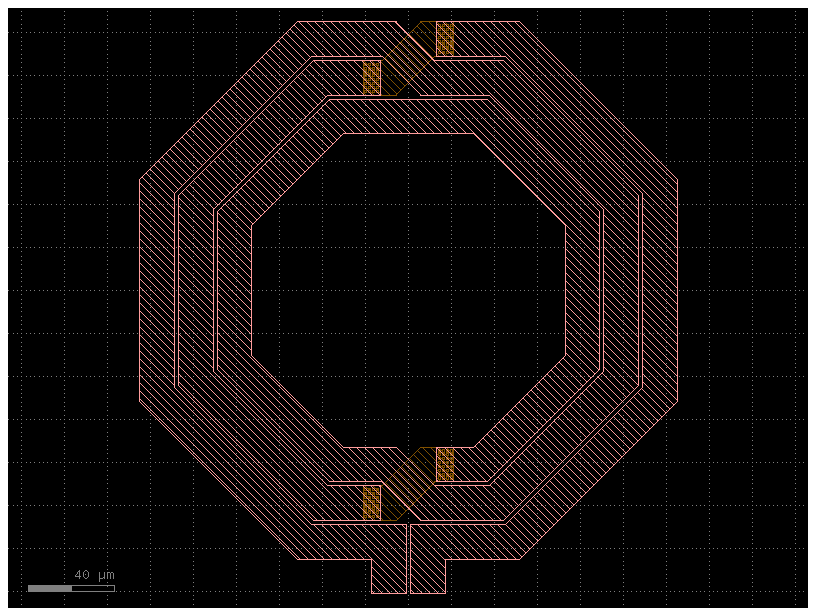

In [2]:
c.plot()

In [3]:
import math
from primitives import (
    _zip,
    Poly,
    routing_geometric_45,
    via_grid,
    mirror_x,
    make_aspect_shift_y,
    map_y,
)

In [4]:
@gf.cell
def symmetric_inductor(
    outer_diameter: float = 130.0,
    turns: int = 3,
    sides: int = 8,
    width: float = 10.0,
    spacing: float = 4.0,
    center_tap: bool = False,
    via_extent: float = 2.0,
    via_spacing: float = 0.8,
    via_width: float = 1.0,
    via_in_metal: float = 0.45,
    port_spacing: float | None = None,
    aspect_ratio: float = 1.0,
    layer_winding: LayerSpec = "TopMetal2drawing",
    layer_underpass: LayerSpec = "TopMetal1drawing",
    layer_via: LayerSpec = "TopVia2drawing",
) -> Component:
    """Symmetric (differential) spiral inductor for on-chip RF applications.

    Two mirrored half-spirals share a common axis, forming a balanced
    differential structure. Each half-turn is drawn on layer_winding;
    inter-turn bridges (crossings) are routed on layer_underpass and
    connected through via arrays on layer_via.

    An optional center tap brings the electrical midpoint out as a third
    port, useful for single-ended biasing or center-tapped baluns.

    Args:
        outer_diameter: Outer diameter of the spiral in micrometers.
        turns: Number of complete turns per half-spiral.
        sides: Number of polygon sides per full turn (8 = octagonal).
        width: Metal trace width in micrometers.
        spacing: Gap between adjacent turns in micrometers.
        center_tap: When True, adds a center-tap port CT at the
            electrical midpoint of the differential winding.
        via_extent: Height of the via landing pad in micrometers.
            Controls how far the via column extends beyond the trace width.
        via_spacing: Gap between individual via squares in micrometers.
        via_width: Side length of each via square in micrometers.
        via_in_metal: Minimum metal enclosure around each via in micrometers.
        port_spacing: Gap between the two signal ports in micrometers.
            Defaults to the inter-turn spacing if None.
        aspect_ratio: Y-axis scale factor for non-square spirals (1.0 = symmetric).
        layer_winding: Metal layer for the main spiral windings.
        layer_underpass: Metal layer for the inter-turn crossing bridges.
        layer_via: Via layer connecting layer_winding to layer_underpass
            at each inter-turn crossing.

    Returns:
        Component with 2 or 3 RF ports:
          P1  ->  negative terminal  (layer_winding, left side)
          P2  ->  positive terminal  (layer_winding, right side)
          CT  ->  center tap terminal (if center_tap=True)
    """
    c = Component()
    ps = port_spacing if port_spacing is not None else spacing

    PI = math.pi
    SQRT2 = math.sqrt(2)
    v = width / math.cos(PI / sides)
    s = (spacing + width) / math.cos(PI / sides)
    R1 = outer_diameter / 2 / math.cos(PI / sides)
    R2 = R1 - v

    n_half = sides // 2
    left_angles = [PI * (0.5 + (i + 0.5) * 2 / sides) for i in range(n_half)]
    right_angles = [PI * (-0.5 + (i + 0.5) * 2 / sides) for i in range(n_half)]
    sep_total = width + spacing + (SQRT2 - 1) * (2 * spacing + width)

    pw: list[Poly] = []  # windings
    pc: list[Poly] = []  # crossings
    pct: list[Poly] = []  # center tap
    pv: list[Poly] = []  # vias

    for winding in range(turns):
        # Left section
        x_out = [R1 * math.cos(p) for p in left_angles]
        y_out = [R1 * math.sin(p) for p in left_angles]
        x_in = [R2 * math.cos(p) for p in left_angles]
        y_in = [R2 * math.sin(p) for p in left_angles]

        if winding == turns - 1:
            if turns % 2 == 0:
                x_out = [-sep_total / 2, *x_out, 0]
                x_in = [-sep_total / 2, *x_in, 0]
            else:
                x_out = [0, *x_out, -sep_total / 2]
                x_in = [0, *x_in, -sep_total / 2]
        else:
            x_out = [-sep_total / 2, *x_out, -sep_total / 2]
            x_in = [-sep_total / 2, *x_in, -sep_total / 2]

        y_out = [y_out[0], *y_out, y_out[-1]]
        y_in = [y_in[0], *y_in, y_in[-1]]
        pw.append(_zip([*x_out, *reversed(x_in)], [*y_out, *reversed(y_in)]))

        # Right section
        x_out = [R1 * math.cos(p) for p in right_angles]
        y_out = [R1 * math.sin(p) for p in right_angles]
        x_in = [R2 * math.cos(p) for p in right_angles]
        y_in = [R2 * math.sin(p) for p in right_angles]

        if winding == turns - 1:
            if turns % 2 == 0:
                x_out = [0, *x_out, sep_total / 2]
                x_in = [0, *x_in, sep_total / 2]
            else:
                x_out = [sep_total / 2, *x_out, 0]
                x_in = [sep_total / 2, *x_in, 0]
        else:
            x_out = [sep_total / 2, *x_out, sep_total / 2]
            x_in = [sep_total / 2, *x_in, sep_total / 2]

        y_out = [y_out[0], *y_out, y_out[-1]]
        y_in = [y_in[0], *y_in, y_in[-1]]
        pw.append(_zip([*x_out, *reversed(x_in)], [*y_out, *reversed(y_in)]))

        # Crossings
        if winding != turns - 1:
            h = (
                R1 * math.sin(PI * (0.5 - 1 / sides))
                if winding % 2 == 0
                else (-R2 + s) * math.sin(PI * (0.5 - 1 / sides))
            )

            pc.append(
                routing_geometric_45(
                    width, spacing, 0, h - width - spacing / 2, via_extent
                )
            )
            cross_top = routing_geometric_45(
                width, spacing, 0, h - width - spacing / 2, 0
            )
            pw.append(mirror_x(cross_top))

            for cx, cy in [
                (-sep_total / 2 - width / 2, h - 3 * width / 2 - spacing),
                (sep_total / 2 + width / 2, h - width / 2),
            ]:
                dx = math.copysign(1, cx) * (via_extent - width) / 2
                pv += via_grid(
                    cx + dx,
                    cy,
                    via_extent - 2 * via_in_metal,
                    width - 2 * via_in_metal,
                    via_spacing,
                    via_width,
                )

        R1 -= s
        R2 -= s

    # Center tap
    if center_tap:
        x_ct = [-width / 2, -width / 2, width / 2, width / 2]
        if turns % 2 != 0:
            if turns <= 2:
                y_ct = [
                    -outer_diameter / 2,
                    outer_diameter / 2 - spacing * (turns - 1) - width * (turns - 1),
                    outer_diameter / 2 - spacing * (turns - 1) - width * (turns - 1),
                    -outer_diameter / 2,
                ]
            else:
                y_ct = [
                    -outer_diameter / 2 + width - via_extent,
                    outer_diameter / 2
                    - spacing * (turns - 1)
                    - width * (turns - 1)
                    - via_extent,
                    outer_diameter / 2
                    - spacing * (turns - 1)
                    - width * (turns - 1)
                    - via_extent,
                    -outer_diameter / 2 + width - via_extent,
                ]
        else:
            if turns <= 2:
                y_ct = [
                    -outer_diameter / 2,
                    -outer_diameter / 2 + spacing * (turns - 1) + width * (turns - 1),
                    -outer_diameter / 2 + spacing * (turns - 1) + width * (turns - 1),
                    -outer_diameter / 2,
                ]
            else:
                y_ct = [
                    -outer_diameter / 2 + width - via_extent,
                    -outer_diameter / 2 + spacing * (turns - 1) + width * (turns - 1),
                    -outer_diameter / 2 + spacing * (turns - 1) + width * (turns - 1),
                    -outer_diameter / 2 + width - via_extent,
                ]

        if turns <= 2:
            pw.append(_zip(x_ct, y_ct))
        else:
            pct.append(_zip(x_ct, y_ct))
            if turns % 2 != 0:
                x_ct1, y_ct1 = (
                    0,
                    outer_diameter / 2
                    - spacing * (turns - 1)
                    - width * (turns - 1)
                    - via_extent / 2,
                )
                x_ct2, y_ct2 = (
                    0,
                    -outer_diameter / 2 + width / 2 + (width - via_extent) / 2,
                )
            else:
                x_ct1, y_ct1 = (
                    0,
                    -outer_diameter / 2
                    + spacing * (turns - 1)
                    + width * turns
                    - width
                    + via_extent / 2,
                )
                x_ct2, y_ct2 = 0, -outer_diameter / 2 + width - via_extent / 2

            xvp1 = [
                x_ct1 - width / 2,
                x_ct1 - width / 2,
                x_ct1 + width / 2,
                x_ct1 + width / 2,
            ]
            yvp1 = [
                y_ct1 - via_extent / 2,
                y_ct1 + via_extent / 2,
                y_ct1 + via_extent / 2,
                y_ct1 - via_extent / 2,
            ]
            xvp2 = [
                x_ct2 - width / 2,
                x_ct2 - width / 2,
                x_ct2 + width / 2,
                x_ct2 + width / 2,
            ]
            yvp2 = [
                y_ct2 - via_extent / 2,
                y_ct2 + via_extent / 2,
                y_ct2 + via_extent / 2,
                y_ct2 - via_extent / 2,
            ]

            pw.append(_zip(xvp1, yvp1))
            pc.append(_zip(xvp1, yvp1))
            pct.append(_zip(xvp1, yvp1))
            pc.append(_zip(xvp2, yvp2))
            pct.append(_zip(xvp2, yvp2))

            for cx, cy in [(x_ct1, y_ct1), (x_ct2, y_ct2)]:
                pv += via_grid(
                    cx,
                    cy,
                    width - 2 * via_in_metal,
                    via_extent - 2 * via_in_metal,
                    via_spacing,
                    via_width,
                )

    # Base port shapes
    pxo = ps + width if center_tap else (ps + width) / 2
    x_port = [
        -sep_total / 2,
        -pxo + width / 2,
        -pxo + width / 2,
        -pxo - width / 2,
        -pxo - width / 2,
        -sep_total / 2,
    ]
    y_port = [
        -outer_diameter / 2 + width,
        -outer_diameter / 2 + width,
        -outer_diameter / 2 - width,
        -outer_diameter / 2 - width,
        -outer_diameter / 2,
        -outer_diameter / 2,
    ]

    if center_tap:
        pw.append(
            _zip(
                [-width / 2, -width / 2, width / 2, width / 2],
                [
                    -outer_diameter / 2 - width,
                    -outer_diameter / 2 + width,
                    -outer_diameter / 2 + width,
                    -outer_diameter / 2 - width,
                ],
            )
        )

    pw.append(_zip(x_port, y_port))
    pw.append(_zip([-x for x in x_port], y_port))

    # Apply aspect ratio shifting and scaling
    shift_y = make_aspect_shift_y(outer_diameter, aspect_ratio)

    windings_scaled = [map_y(p, shift_y) for p in pw] if aspect_ratio != 1.0 else pw
    crossings_scaled = [map_y(p, shift_y) for p in pc] if aspect_ratio != 1.0 else pc
    centertap_scaled = [map_y(p, shift_y) for p in pct] if aspect_ratio != 1.0 else pct
    vias_scaled = [map_y(p, shift_y) for p in pv] if aspect_ratio != 1.0 else pv

    # Add geometries to component
    for poly in windings_scaled:
        c.add_polygon(poly, layer=layer_winding)

    for poly in crossings_scaled:
        c.add_polygon(poly, layer=layer_underpass)

    for poly in centertap_scaled:
        layer_ct = layer_winding if turns <= 2 else layer_underpass
        c.add_polygon(poly, layer=layer_ct)

    for poly in vias_scaled:
        c.add_polygon(poly, layer=layer_via)

    # Calculate port Y position with shift logic
    port_y = -outer_diameter / 2 - width
    port_y_scaled = shift_y(port_y) if aspect_ratio != 1.0 else port_y

    # Add ports natively into gdsfactory
    c.add_port(
        "P1",
        center=(-pxo, port_y_scaled),
        width=width,
        orientation=270.0,
        layer=layer_winding,
    )
    c.add_port(
        "P2",
        center=(pxo, port_y_scaled),
        width=width,
        orientation=270.0,
        layer=layer_winding,
    )

    if center_tap:
        layer_ct = layer_winding if turns <= 2 else layer_underpass
        c.add_port(
            "CT",
            center=(0, port_y_scaled),
            width=width,
            orientation=270.0,
            layer=layer_ct,
        )

    return c

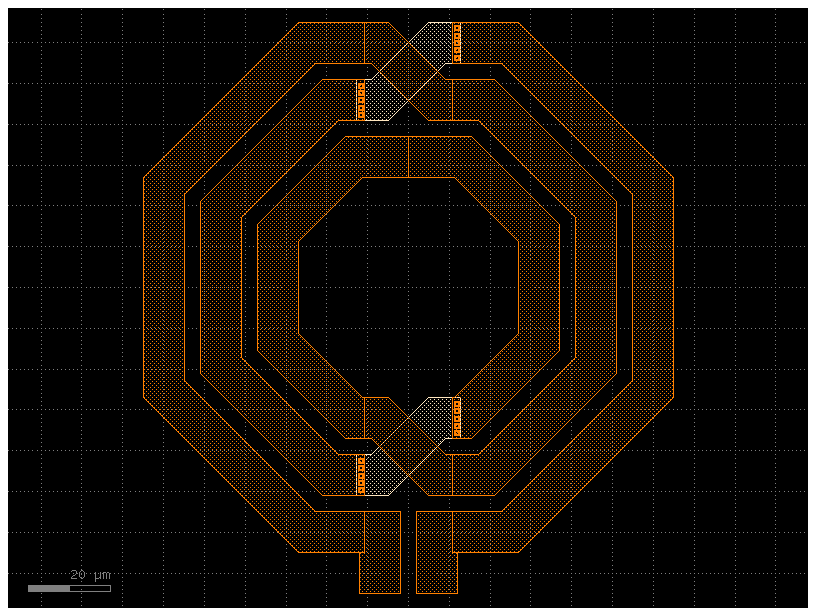

In [5]:
cc = symmetric_inductor()
cc.plot()

In [6]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-symmetric_inductor")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# Configure ports
sim.add_port("P1", layer="topmetal2", geometry="inplane", excited=True)
sim.add_port("P2", layer="topmetal2", geometry="inplane", excited=True)
# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [7]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=1.5)
sim.write_config()

Info    : Reading 'palace-sim-symmetric_inductor/palace.msh'...
Info    : 30933 nodes
Info    : 224561 elements
Info    : Done reading 'palace-sim-symmetric_inductor/palace.msh'                                                
Info    : Reading 'palace-sim-symmetric_inductor/palace.msh'...
Info    : 30933 nodes
Info    : 224561 elements
Info    : Done reading 'palace-sim-symmetric_inductor/palace.msh'                                                


PosixPath('palace-sim-symmetric_inductor/config.json')

In [8]:
sim.plot_mesh(show_groups=["metal", "via", "P"])

Widget(value='<iframe src="http://localhost:34635/index.html?ui=P_0x72b5f53834a0_0&reconnect=auto" class="pyvi…